<a href="https://colab.research.google.com/github/dnanaat/PCVK_Genap_2026/blob/main/Week3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv

print(' Mengubah tingkat kecerahan citra ')
print('--------------------------------')
try:
    brightness = int(input('Masukkan nilai kecerahan: '))
except ValueError:
    print('Error, not a number')

#sesuaikan dengan file dan folder di drive Anda
original = cv.imread('/content/drive/MyDrive/PCVK/balap.jpg')
brightness_image = np.zeros(original.shape, original.dtype)

#akses per piksel
#np.clip digunakan untuk melakukan truncate pixel (nilai dibatasi antara 0-255)
# for y in range(original.shape[0]):
#     for x in range(original.shape[1]):
#         for c in range(original.shape[2]):
#             brightness_image[y,x,c] = np.clip(original[y,x,c] + brightness, 0, 255)

#cara simple tanpa for loop
brightness_image = cv.convertScaleAbs(original, beta=brightness)

final_frame = cv.hconcat((original, brightness_image))
cv2_imshow(final_frame)

In [ ]:
#TUGAS PRAKTIKUM

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

#1. INVERSE CITRA

img_peppers = cv.imread('/content/drive/MyDrive/PCVK/paprika.jpg')
img_peppersRS = cv.resize(img_peppers, (600,400))

inverse_img = 255 - img_peppersRS

print("Tugas 1: Inverse Citra")
cv2_imshow(cv.hconcat((img_peppersRS, inverse_img)))
print('\n')

Tugas 2: Mengubah kontras dan tingkat kecerahan citra
Masukkan tingkat kecerahan: 10
Masukkan kontras: 1.5


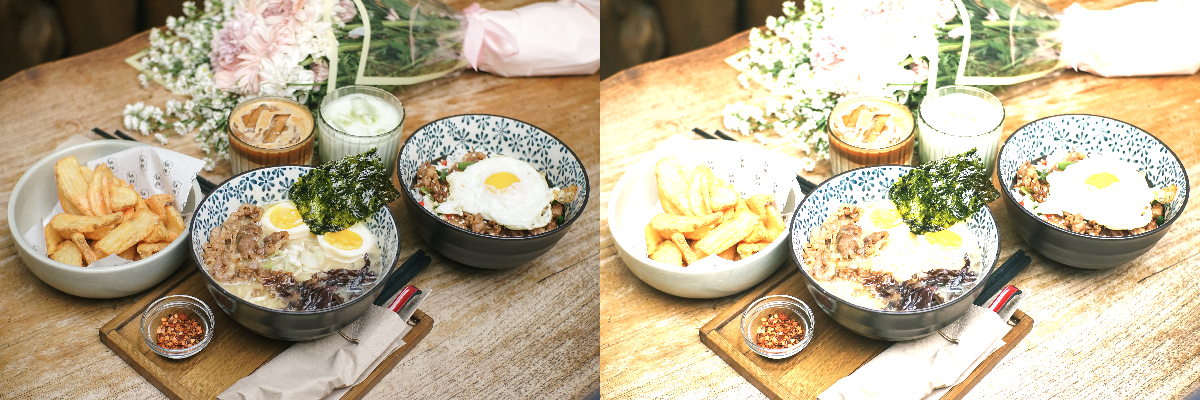

In [45]:
#2. TRANSFORMASI CONTRAST

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

img_food = cv.imread('/content/drive/MyDrive/PCVK/makanan.jpg')
img_foodRS = cv.resize(img_food, (600,400))


print("Tugas 2: Mengubah kontras dan tingkat kecerahan citra")
try:
    brightness = int(input('Masukkan tingkat kecerahan: '))
    contrast = float(input('Masukkan kontras: '))
except ValueError:
    print('Error, not a number')
    brightness, contrast = 0, 1.0

# Parameter alpha untuk kontras, beta untuk kecerahan
contrast_img = cv.convertScaleAbs(img_foodRS, alpha=contrast, beta=brightness)

cv2_imshow(cv.hconcat((img_foodRS, contrast_img)))

Tugas 3: Mengubah tingkat kecerahan citra dengan Transformasi Log
Masukkan nilai kecerahan: 50


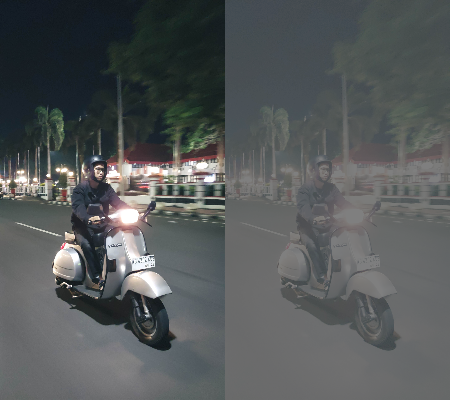

In [132]:
#3. TRANSFORMASI LOGARITHMIC BRIGHTNESS

import cv2 as cv
import numpy as np
from google.colab.patches import cv2_imshow

img_dark = cv.imread('/content/drive/MyDrive/PCVK/vespa.jpg')
img_darkRS = cv.resize(img_dark, (225, 400))

print("Tugas 3: Mengubah tingkat kecerahan citra dengan Transformasi Log")

try:
    c_fac = int(input('Masukkan nilai kecerahan: '))
except ValueError:
    print('Error, not a number')
    c_fac = 0

c_factor = (c_fac / 100)

# 1. Konversi gambar ke float
img_float = img_darkRS.astype(np.float32)
# 2. Hitung nilai c standar agar output berada di rentang 0-255
max_val = np.max(img_float)
c = (255 / np.log(1 + max_val)) * c_factor
# 3. Aplikasikan transformasi logaritma: s = c * log(1 + r)
log_img = c * np.log(1 + img_float)
# 4. Batasi nilai piksel pada rentang [0, 255] dan ubah kembali ke uint8
log_img = np.clip(log_img, 0, 255).astype(np.uint8)
# Tampilkan gambar asli vs hasil transformasi
cv2_imshow(cv.hconcat((img_darkRS, log_img)))

Tugas 4: Transformasi Grayscale


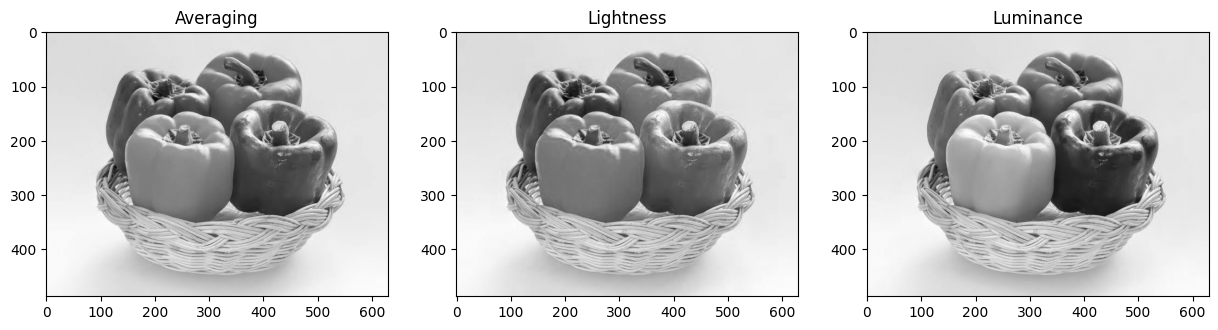

In [133]:
#4. TRANFORMASI GRAYSCALE

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

print("Tugas 4: Transformasi Grayscale")

# Memisahkan channel B, G, R dan mengubah ke float untuk perhitungan
b, g, r = cv.split(img_peppers.astype(np.float32))

# a. Averaging
avg_gray = ((b + g + r) / 3).astype(np.uint8)

# b. Lightness
max_rgb = np.maximum(np.maximum(r, g), b)
min_rgb = np.minimum(np.minimum(r, g), b)
light_gray = ((max_rgb + min_rgb) / 2).astype(np.uint8)

# c. Luminance
lumin_gray = (0.21 * r + 0.72 * g + 0.07 * b).astype(np.uint8)

# Menampilkan hasil
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1), plt.imshow(avg_gray, cmap='gray'), plt.title('Averaging')
plt.subplot(1, 3, 2), plt.imshow(light_gray, cmap='gray'), plt.title('Lightness')
plt.subplot(1, 3, 3), plt.imshow(lumin_gray, cmap='gray'), plt.title('Luminance')
plt.show()

Tugas 5: Isolasi Warna Merah pada Citra


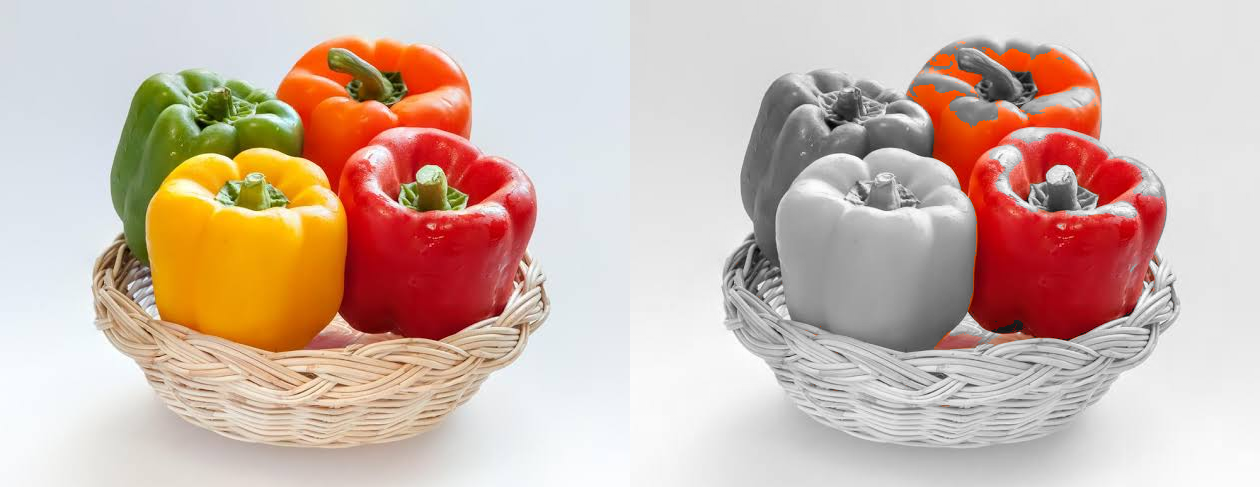

In [134]:
print("Tugas 5: Isolasi Warna Merah pada Citra")

# Convert ke HSV
hsv = cv.cvtColor(img_peppers, cv.COLOR_BGR2HSV)

# Masking warna merah (Merah ada di dua ujung spektrum HSV: 0-10 dan 160-180)
lower_red1 = np.array([0, 100, 100])
upper_red1 = np.array([10, 255, 255])
lower_red2 = np.array([160, 100, 100])
upper_red2 = np.array([180, 255, 255])

mask1 = cv.inRange(hsv, lower_red1, upper_red1)
mask2 = cv.inRange(hsv, lower_red2, upper_red2)
mask_red = mask1 | mask2

# Buat versi citra grayscale 3-channel agar dimensinya cocok untuk digabung
gray_3channel = cv.cvtColor(lumin_gray, cv.COLOR_GRAY2BGR)

# Gunakan np.where untuk kondisi: Jika pixel masuk di area mask merah, ambil warna asli. Jika tidak, ambil grayscale.
isolated_img = np.where(mask_red[:, :, None] > 0, img_peppers, gray_3channel)

cv2_imshow(cv.hconcat((img_peppers, isolated_img)))

In [ ]:
print('Tugas 6: Gamma Correction pada citra')
print('--------------------------------')
try:
    gamma = float(input('Masukkan nilai Gamma: '))
except ValueError:
    print('Error, not a number')
    gamma = 1.0

# Mencegah error pembagian dengan nol
gamma = gamma if gamma > 0 else 0.1
inv_gamma = 1.0 / gamma

# Membuat Look Up Table (LUT) untuk kecepatan optimal
table = np.array([((i / 255.0) ** inv_gamma) * 255 for i in np.arange(0, 256)]).astype(np.uint8)

# Mengaplikasikan LUT ke gambar
gamma_corrected = cv.LUT(img_balapRS, table)

cv2_imshow(cv.hconcat((img_balapRS, gamma_corrected)))

Tugas 7: Simulasi Image Depth
Masukkan bit depth tujuan (1-8): 3
Bit depth awal: 8 bit
Bit depth tujuan: 3 bit
Jumlah level: 8


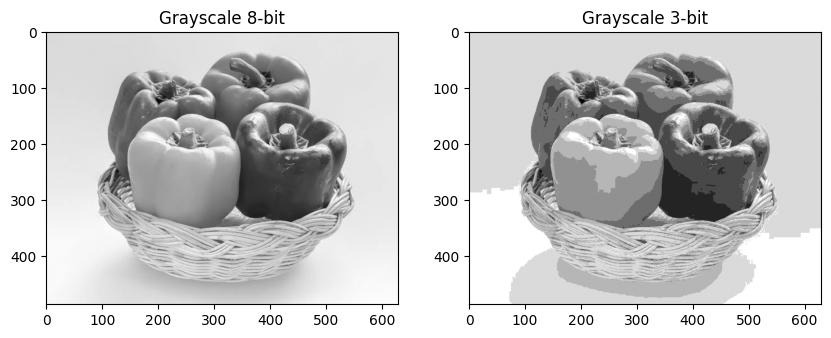

In [136]:
print("Tugas 7: Simulasi Image Depth")
# Baca citra sebagai Grayscale
original_gray = cv.imread('/content/drive/MyDrive/PCVK/paprika.jpg', cv.IMREAD_GRAYSCALE)

try:
    bit_depth = int(input("Masukkan bit depth tujuan (1-8): "))
except ValueError:
    print('Error, not a number')
    bit_depth = 8

# Mencegah nilai di luar 1-8
bit_depth = np.clip(bit_depth, 1, 8)
level = 255.0 / ((2 ** bit_depth) - 1)

# Operasi matriks (Vectorized)
depth_image = np.round(original_gray / level) * level
depth_image = depth_image.astype(np.uint8)

print(f"Bit depth awal: 8 bit")
print(f"Bit depth tujuan: {bit_depth} bit")
print(f"Jumlah level: {2 ** bit_depth}")

# Menampilkan hasil
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1), plt.imshow(original_gray, cmap='gray'), plt.title('Grayscale 8-bit')
plt.subplot(1, 2, 2), plt.imshow(depth_image, cmap='gray'), plt.title(f'Grayscale {bit_depth}-bit')
plt.show()

In [142]:
print("Tugas 8: Average Denoising & PSNR")
import cv2 as cv
import numpy as np
import glob
import math

# 1. Fungsi untuk menghitung nilai PSNR
def PSNR(img1, img2):
    mse = np.mean((img1.astype(np.float64) - img2.astype(np.float64)) ** 2)
    if mse == 0:
        return 100
    max_pixel = 255.0
    psnr = 20 * math.log10(max_pixel / math.sqrt(mse))
    return psnr

# 2. Membaca citra asli (galaxy.jpg)
img_asli = cv.imread('/content/drive/MyDrive/PCVK/galaxy.jpg', cv.IMREAD_GRAYSCALE)

# 3. Membaca kumpulan 100 citra noise menggunakan glob
cv_img = []
for img_path in glob.glob('/content/drive/MyDrive/PCVK/galaxy.jpg'):
    n = cv.imread(img_path, cv.IMREAD_GRAYSCALE)
    if n is not None:
        cv_img.append(n)

# 4. Daftar jumlah citra yang di-average sesuai tabel modul
jumlah_average = [10, 20, 40, 80, 100]

print("No | Jumlah Citra di Average | Nilai PSNR (dB)")
print("-" * 45)

for idx, N in enumerate(jumlah_average, start=1):
    if N > len(cv_img):
        print(f"Peringatan: Jumlah gambar noise kurang dari {N}")
        continue

    # Proses averaging piksel dari N buah gambar
    avg_img = np.zeros(img_asli.shape, dtype=np.float64)
    for i in range(N):
        avg_img += cv_img[i]

    avg_img = (avg_img / N).astype(np.uint8)

    # Hitung nilai PSNR
    nilai_psnr = PSNR(img_asli, avg_img)

    # Cetak format baris tabel laporan
    print(f"{idx:2d} | {N:23d} | {nilai_psnr:.4f}")

Tugas 8: Average Denoising & PSNR
No | Jumlah Citra di Average | Nilai PSNR (dB)
---------------------------------------------
Peringatan: Jumlah gambar noise kurang dari 10
Peringatan: Jumlah gambar noise kurang dari 20
Peringatan: Jumlah gambar noise kurang dari 40
Peringatan: Jumlah gambar noise kurang dari 80
Peringatan: Jumlah gambar noise kurang dari 100


In [ ]:
print("Tugas 9: Image Masking")
couple_imgORI = cv.imread('/content/drive/MyDrive/PCVK/couple3.jpg')
couple_img = cv.resize(couple_img, (400,600))

# 1. Membuat Mask (Latar hitam, 2 lingkaran putih)
mask = np.zeros(couple_img.shape[:2], dtype=np.uint8)

cv.circle(mask, (150, 180), 50, 255, -1) # Lingkaran kiri
cv.circle(mask, (260, 200), 50, 255, -1) # Lingkaran kanan

# 2. Operasi Logika OpenCV
# AND: Hanya menampilkan area citra yang tertutupi area putih pada mask
res_and = cv.bitwise_and(couple_img, couple_img, mask=mask)

# OR: Menampilkan citra jika mask-nya putih (karena putih=255, OR dengan 255 pasti 255/putih)
# Di OpenCV butuh perlakuan sedikit beda agar hasilnya sesuai ekspektasi logika dasar
mask_3ch = cv.cvtColor(mask, cv.COLOR_GRAY2BGR)
res_or = cv.bitwise_or(couple_img, mask_3ch)

# NOT: Komplemen / membalik warna asli menjadi negatif
res_not = cv.bitwise_not(couple_img)

# XOR: Exclusive OR (Jika pixel citra dan mask sama, hasil 0. Jika beda, 1)
res_xor = cv.bitwise_xor(couple_img, mask_3ch)

# NAND: NOT AND (Kebalikan dari hasil AND)
res_nand = cv.bitwise_not(res_and)

# Menampilkan salah satu hasil masking (AND)
cv2_imshow(cv.hconcat((couple_img, res_and)))
cv2_imshow(cv.hconcat((couple_img, res_or)))
cv2_imshow(cv.hconcat((couple_img, res_not)))
cv2_imshow(cv.hconcat((couple_img, res_xor)))
cv2_imshow(cv.hconcat((couple_img, res_nand)))

In [ ]:
print("Tugas 10: Foto Malam Hari")

# Silakan ganti path ini dengan foto malam hari yang Anda miliki
foto_malam = '/content/drive/MyDrive/PCVK/malam.jpg'
img_malam = cv.imread(foto_malam)

if img_malam is None:
    print("Gambar tidak ditemukan. Tolong upload foto malam hari dan sesuaikan path-nya ya!")
else:
    # Menggunakan Gamma Correction untuk mengangkat detail area gelap
    # Nilai gamma < 1 akan mencerahkan gambar secara non-linier
    gamma_malam = 0.6
    inv_gamma = 1.0 / gamma_malam

    # Membuat Look Up Table (LUT) untuk optimasi kecepatan
    table = np.array([((i / 255.0) ** inv_gamma) * 255 for i in np.arange(0, 256)]).astype(np.uint8)

    # Mengaplikasikan LUT
    hasil_malam = cv.LUT(img_malam, table)

    # Menampilkan perbandingan dengan Matplotlib agar lebih lebar
    plt.figure(figsize=(15, 7))

    # OpenCV menggunakan BGR, jadi kita convert ke RGB agar warna Matplotlib sesuai
    plt.subplot(1, 2, 1)
    plt.imshow(cv.cvtColor(img_malam, cv.COLOR_BGR2RGB))
    plt.title('Foto Asli (Malam Hari)')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(cv.cvtColor(hasil_malam, cv.COLOR_BGR2RGB))
    plt.title(f'Gamma Correction (Gamma = {gamma_malam})')
    plt.axis('off')

    plt.show()

Tugas 11: Perbaikan Kualitas Citra crayfish.jpg


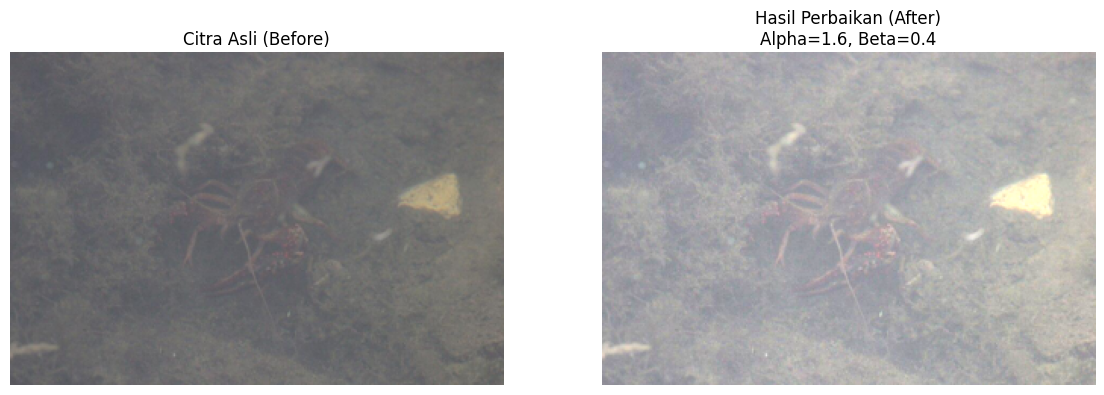

In [139]:
print("Tugas 11: Perbaikan Kualitas Citra crayfish.jpg")

# Sesuaikan path direktori ke tempat penyimpanan crayfish.jpg Anda
path_crayfish = '/content/drive/MyDrive/PCVK/crayfish.png'
img_crayfish = cv.imread(path_crayfish)

if img_crayfish is None:
    print("Gambar crayfish.jpg tidak ditemukan. Periksa kembali path folder Anda!")
else:
    # Menentukan parameter terbaik untuk memperbaiki kontras dan kecerahan
    # Alpha (> 1.0) untuk menaikkan kontras, Beta (> 0) untuk mencerahkan
    alpha_val = 1.6
    beta_val = 0.4

    # Menerapkan transformasi linier kontras & brightness
    improved_crayfish = cv.convertScaleAbs(img_crayfish, alpha=alpha_val, beta=beta_val)

    # Menampilkan perbandingan Before - After menggunakan Matplotlib
    plt.figure(figsize=(14, 6))

    plt.subplot(1, 2, 1)
    plt.imshow(cv.cvtColor(img_crayfish, cv.COLOR_BGR2RGB))
    plt.title('Citra Asli (Before)')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(cv.cvtColor(improved_crayfish, cv.COLOR_BGR2RGB))
    plt.title(f'Hasil Perbaikan (After)\nAlpha={alpha_val}, Beta={beta_val}')
    plt.axis('off')

    plt.show()